사용자 정의 데이터 활용 이미지 분류

In [1]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 4.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no suc

In [2]:
# 필요 라이브러리 설치

!pip install torchviz | tail -n 1
!pip install torchinfo | tail -n 1
w = !apt install tree
print(w[-2])

Setting up tree (2.0.2-1) ...


런타임 다시 시작

In [1]:
# 라이브러리 임포트

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 폰트 관련 용도
import matplotlib.font_manager as fm

# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()

In [2]:
# 파이토치 관련 라이브러리

import torch
from torch import tensor
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torchviz import make_dot
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import torchvision.datasets as datasets

In [3]:
# warning 표시 끄기
import warnings
warnings.simplefilter('ignore')

# 기본 폰트 설정
plt.rcParams['font.family'] = font_name

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

In [4]:
# GPU 디바이스 할당

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [5]:
# 공통 함수 다운로드
!git clone https://github.com/wikibook/pythonlibs.git

# 공통 함수 불러오기
from pythonlibs.torch_lib1 import *

# 공통 함수 확인
print(README)

Cloning into 'pythonlibs'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 25 (delta 6), reused 25 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 21.10 MiB | 17.93 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Common Library for PyTorch
Author: M. Akaishi


데이터 준비

In [6]:
# 데이터 다운로드
w = !wget -nc https://download.pytorch.org/tutorial/hymenoptera_data.zip

# 결과 확인
print(w[-2])

2026-06-04 01:10:33 (188 MB/s) - ‘hymenoptera_data.zip’ saved [47286322/47286322]


In [7]:
# 압축해제
!unzip -qq -o hymenoptera_data.zip

In [8]:
# 트리 구조 출력
!tree hymenoptera_data

hymenoptera_data
├── train
│   ├── ants
│   │   ├── 0013035.jpg
│   │   ├── 1030023514_aad5c608f9.jpg
│   │   ├── 1095476100_3906d8afde.jpg
│   │   ├── 1099452230_d1949d3250.jpg
│   │   ├── 116570827_e9c126745d.jpg
│   │   ├── 1225872729_6f0856588f.jpg
│   │   ├── 1262877379_64fcada201.jpg
│   │   ├── 1269756697_0bce92cdab.jpg
│   │   ├── 1286984635_5119e80de1.jpg
│   │   ├── 132478121_2a430adea2.jpg
│   │   ├── 1360291657_dc248c5eea.jpg
│   │   ├── 1368913450_e146e2fb6d.jpg
│   │   ├── 1473187633_63ccaacea6.jpg
│   │   ├── 148715752_302c84f5a4.jpg
│   │   ├── 1489674356_09d48dde0a.jpg
│   │   ├── 149244013_c529578289.jpg
│   │   ├── 150801003_3390b73135.jpg
│   │   ├── 150801171_cd86f17ed8.jpg
│   │   ├── 154124431_65460430f2.jpg
│   │   ├── 162603798_40b51f1654.jpg
│   │   ├── 1660097129_384bf54490.jpg
│   │   ├── 167890289_dd5ba923f3.jpg
│   │   ├── 1693954099_46d4c20605.jpg
│   │   ├── 175998972.jpg
│   │   ├── 178538489_bec7649292.jpg
│   │   ├── 1804095607_0341701e1c.jpg
│   │   

Transforms 전처리 정의

In [9]:
# 검증 데이터 : 크기 조절, 중앙 부분 잘라내기, 텐서 변환>>정규화

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),

    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))]
)

# 훈련 데이터 : 데이터 증강 기법 추가
# 검증 데이터 : 크기 조절, 중앙 부분 잘라내기, 텐서 변환>>정규화

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),

    # 텐서 변환은 반드시 정규화 이전에
    # 텐서로 변환되면 value=0 검은색이 [0,1] 사이에서 실행됨
    transforms.ToTensor(),

    transforms.RandomErasing(p=0.5, scale=(0.02,0.33),
                             ratio=(0.3,3.3), value=0, inplace=False),
    # p: probability 증강기법 활용할 확률, 절반만 무작위로 지운다
    # scale=(0.02,0.33) 지워지는 영역의 크기 비율(면적대비 2-33% 사이 사각형 생성)
    # ratio=(0.3,3.3) 사각형의 세로, 가로 비율 aspect ratio
    # 0.3 (가로가 짧고, 세로가 긴 형태)
    # value=0 지워진 영역 채울 색 여기서는 0 (검은색)(옵션: random)
    # inplace=False 원본 수정 여부 (False: 원본 안 건드림)
    # 복사본에 수행한다.

    # 이 함수는 transforms.ToTensor() 다음에 위치해야 함
    # 이미지가 텐서 형태여야만 value=0으로 변경 가능하기 때문에

    # 반드시 정규화는 마지막 단계임
    # 범위가 [-1.0, 1.0] 변경됨
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))]

)

Normalize : 이미지 (픽셀 pixel) >> 정규화(표준화)
- 안정적인 모델 (데이터를 평균 0, 표준편차 1)
- 표준화 (z-score) x - x_mean(평균) / std(표준편차)

- 왜 [0.1] >> [-1, 1] 로 스케일링 되지?
  - ToTensor 이미지 픽셀 >> [0, 1] 사이 값으로 변환
  - 입력값(x) - 평균 >> x - 0.5 >> [-0.5, 0.5]
  - 근데 표준편차 0.5 >> (입력값 - 0.5) / 0.5 >> [-1, 1]


데이터 셋 정의

In [10]:
# base directory
data_dir = 'hymenoptera_data'

# 훈련 데이터 디렉터리와 검증 데이터 디렉터리 지정
import os
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'val')

# join 함수 결과 확인
print(train_dir, test_dir)

# 분류하려는 클래스의 리스트 작성
classes = ['ants', 'bees']

hymenoptera_data/train hymenoptera_data/val


In [11]:
# 데이터셋 정의
# 훈련용
# 훈련1 (데이터 증강 적용할 때)
train_data = datasets.ImageFolder(train_dir, transform=train_transform)

# 훈련2 (데이터 증강 미적용)
train_data2 = datasets.ImageFolder(train_dir, transform=test_transform)

# 검증용
test_data = datasets.ImageFolder(test_dir, transform=test_transform)

In [12]:
print(len(train_data))
print(len(train_data2))
print(len(test_data))

244
244
153


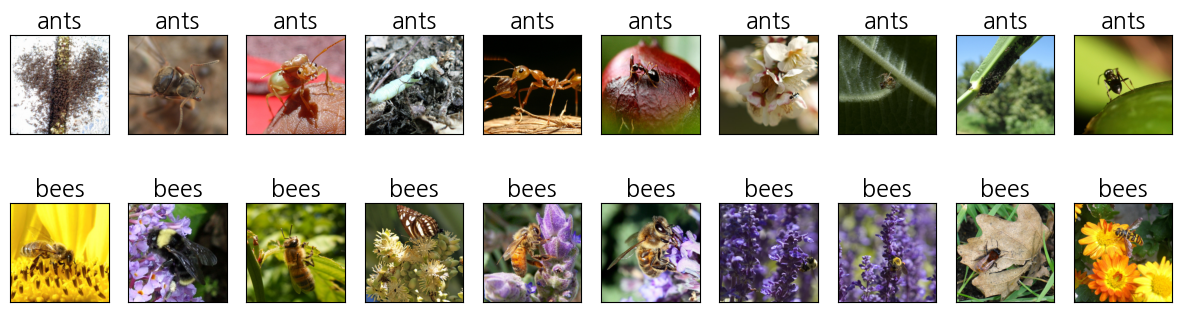

In [13]:
# 검증 데이터 샘플 출력 (처음 10개와 마지막 10개)
plt.figure(figsize=(15, 4))
for i in range(10):
    # 처음 10개
    ax = plt.subplot(2, 10, i + 1)
    image, label = test_data[i]
    img = (np.transpose(image.numpy(), (1, 2, 0)) + 1) / 2
    plt.imshow(img)
    ax.set_title(classes[label])
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # 마지막 10개
    ax = plt.subplot(2, 10, i + 11)
    image, label = test_data[-i - 1]
    img = (np.transpose(image.numpy(), (1, 2, 0)) + 1) / 2
    plt.imshow(img)
    ax.set_title(classes[label])
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

데이터 로더

In [14]:
batch_size = 10

# 훈련용(데이터증강)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

# 검증용
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# 이미지 출력용 (데이터 증강 미적용)

# 훈련용(데이터증강)
train_loader2 = DataLoader(train_data2, batch_size=50, shuffle=True)

# 검증용
test_loader2 = DataLoader(test_data, batch_size=50, shuffle=False)


이미지 출력

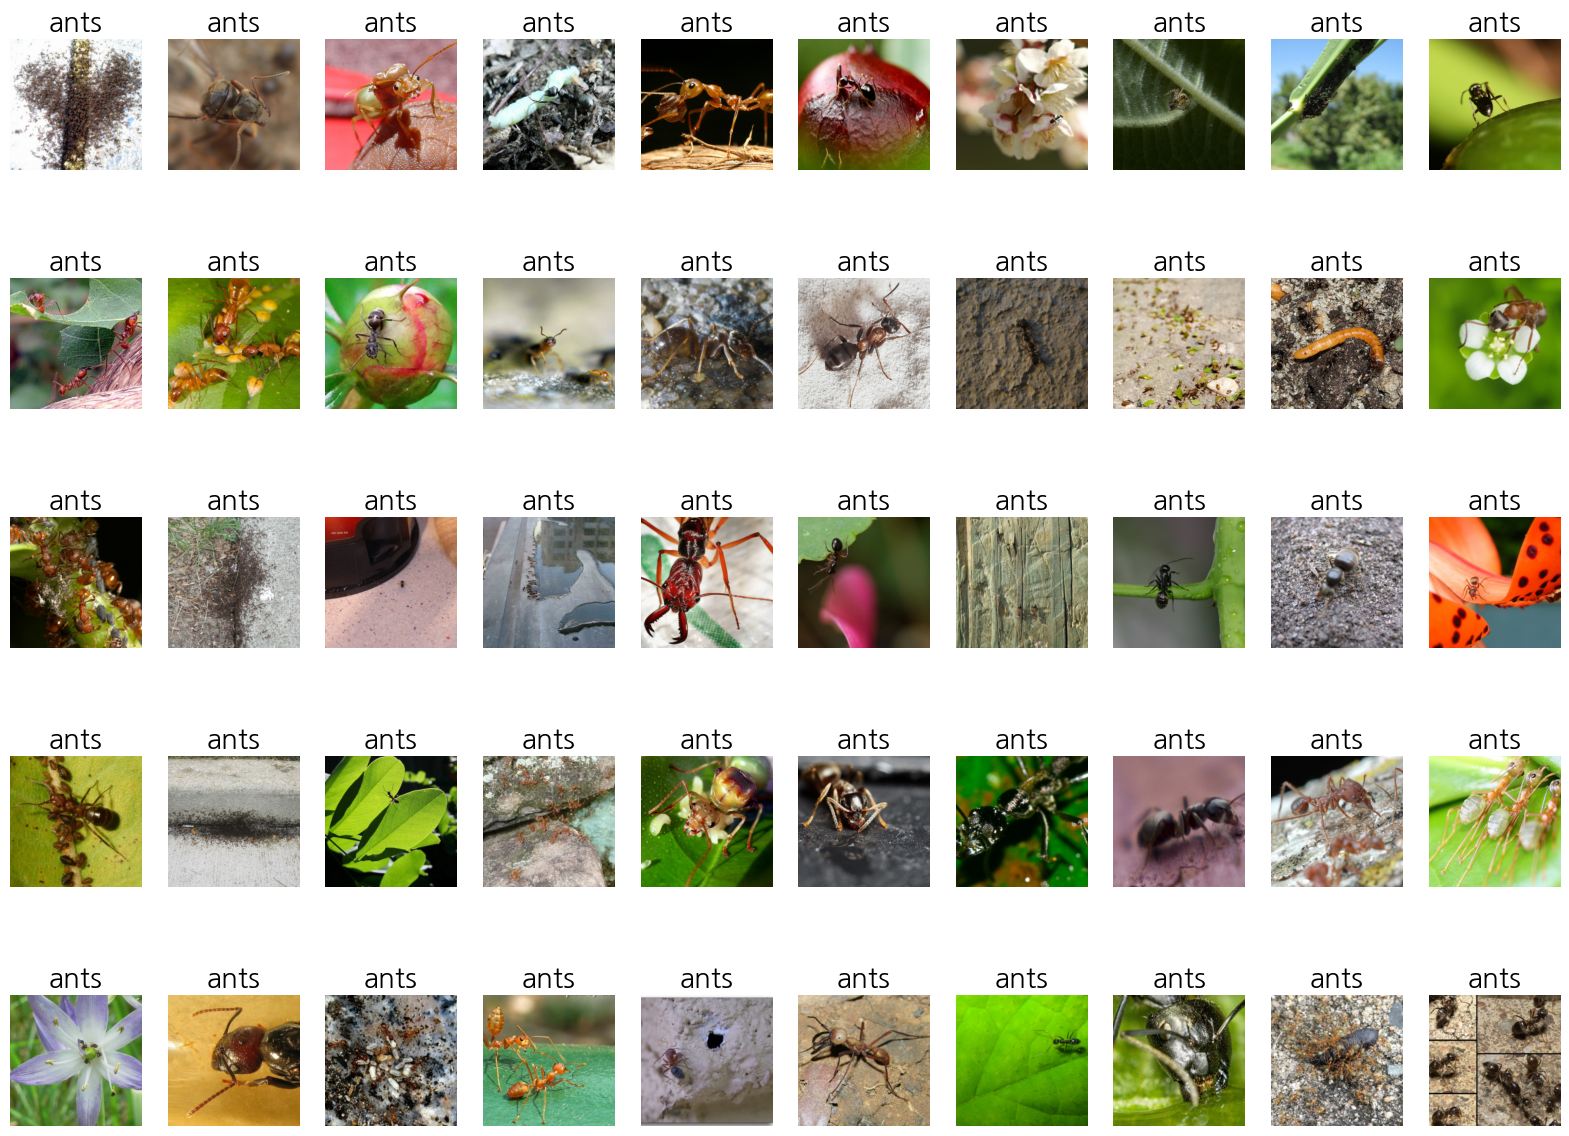

In [15]:
# 검증 데이터 (50건)
torch_seed()
show_images_labels(test_loader2, classes, None, None)
#  None, None 모델의 예측값, 모델 객체

Fine Tuning (파인 튜닝: 미세조정)

In [16]:
from torchvision import models

net = models.vgg19_bn(pretrained=True)

# 난수 고정
torch_seed()

# 최종 노드의 출력 2로 변경 (ants, bees) >> 이진 분류기로 교체
in_features = net.classifier[6].in_features
net.classifier[6] = nn.Linear(in_features, 2)

Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth


100%|██████████| 548M/548M [00:02<00:00, 242MB/s]


In [17]:
# AdaptiveAverage2d 함수 제거
net.avgpool = nn.Identity()
# nn.Identity() 있는 그대로, 아무 작업 안하고 그대로 출력

net = net.to(device)

# 학습률
lr = 0.001

# 손실함수
criterion = nn.CrossEntropyLoss()

# 최적화 함수
# 모델의 모든 파라미터를 업데이트 대상으로 지정 (파인튜닝)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

# history 파일도 동시에 초기화
history = np.zeros((0,5))


In [18]:
# np.zeros((0,5))

# 학습
num_epochs = 5
history = fit(net, optimizer, criterion, num_epochs,
              train_loader, test_loader, device, history)

# loss: 0.01508 acc: 0.94262 val_loss: 0.01338, val_acc: 0.96078
# 과소적합(under-fitting)
# acc: 0.94262보다 val_acc: 0.96078가 높음 (N을 늘려야 함)

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [1/5], loss: 0.04421 acc: 0.78689 val_loss: 0.01152, val_acc: 0.96078


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [2/5], loss: 0.01980 acc: 0.92213 val_loss: 0.01268, val_acc: 0.96732


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [3/5], loss: 0.02125 acc: 0.91803 val_loss: 0.01160, val_acc: 0.96732


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [4/5], loss: 0.01575 acc: 0.93033 val_loss: 0.01605, val_acc: 0.94771


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [5/5], loss: 0.01433 acc: 0.93443 val_loss: 0.01298, val_acc: 0.95425


초기상태 : 손실 : 0.01152  정확도 : 0.96078
최종상태 : 손실 : 0.01298 정확도 : 0.95425


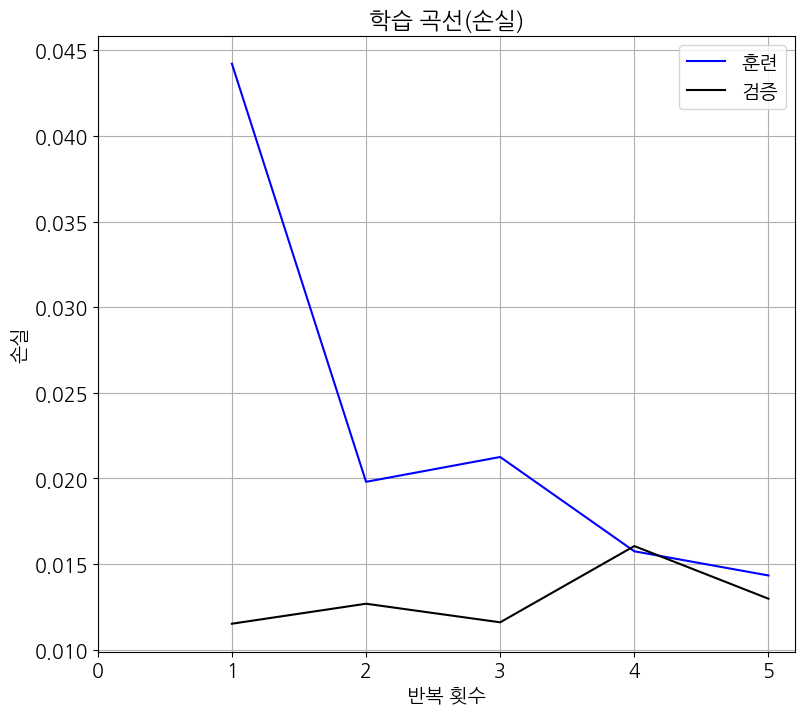

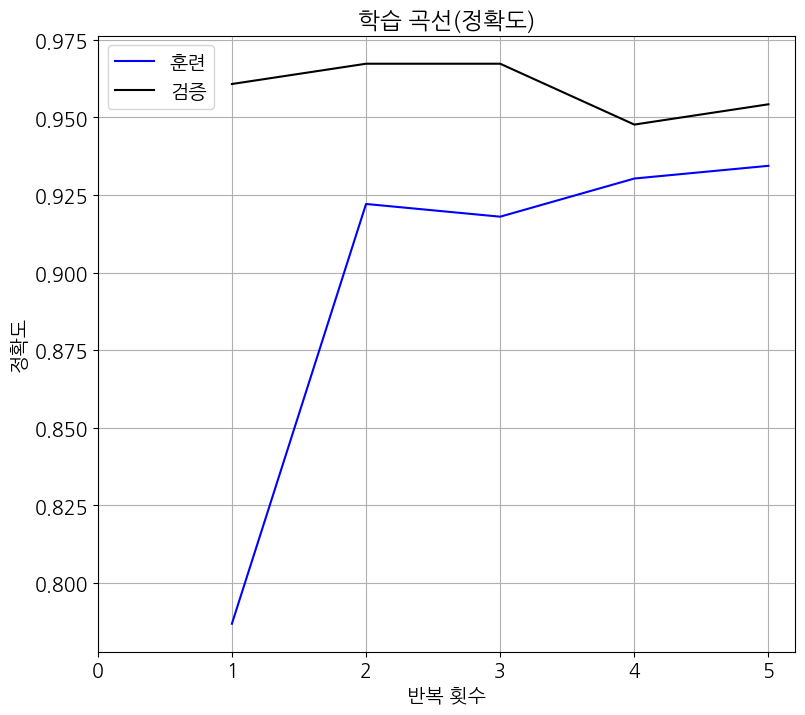

In [19]:
# 결과학습
evaluate_history(history)

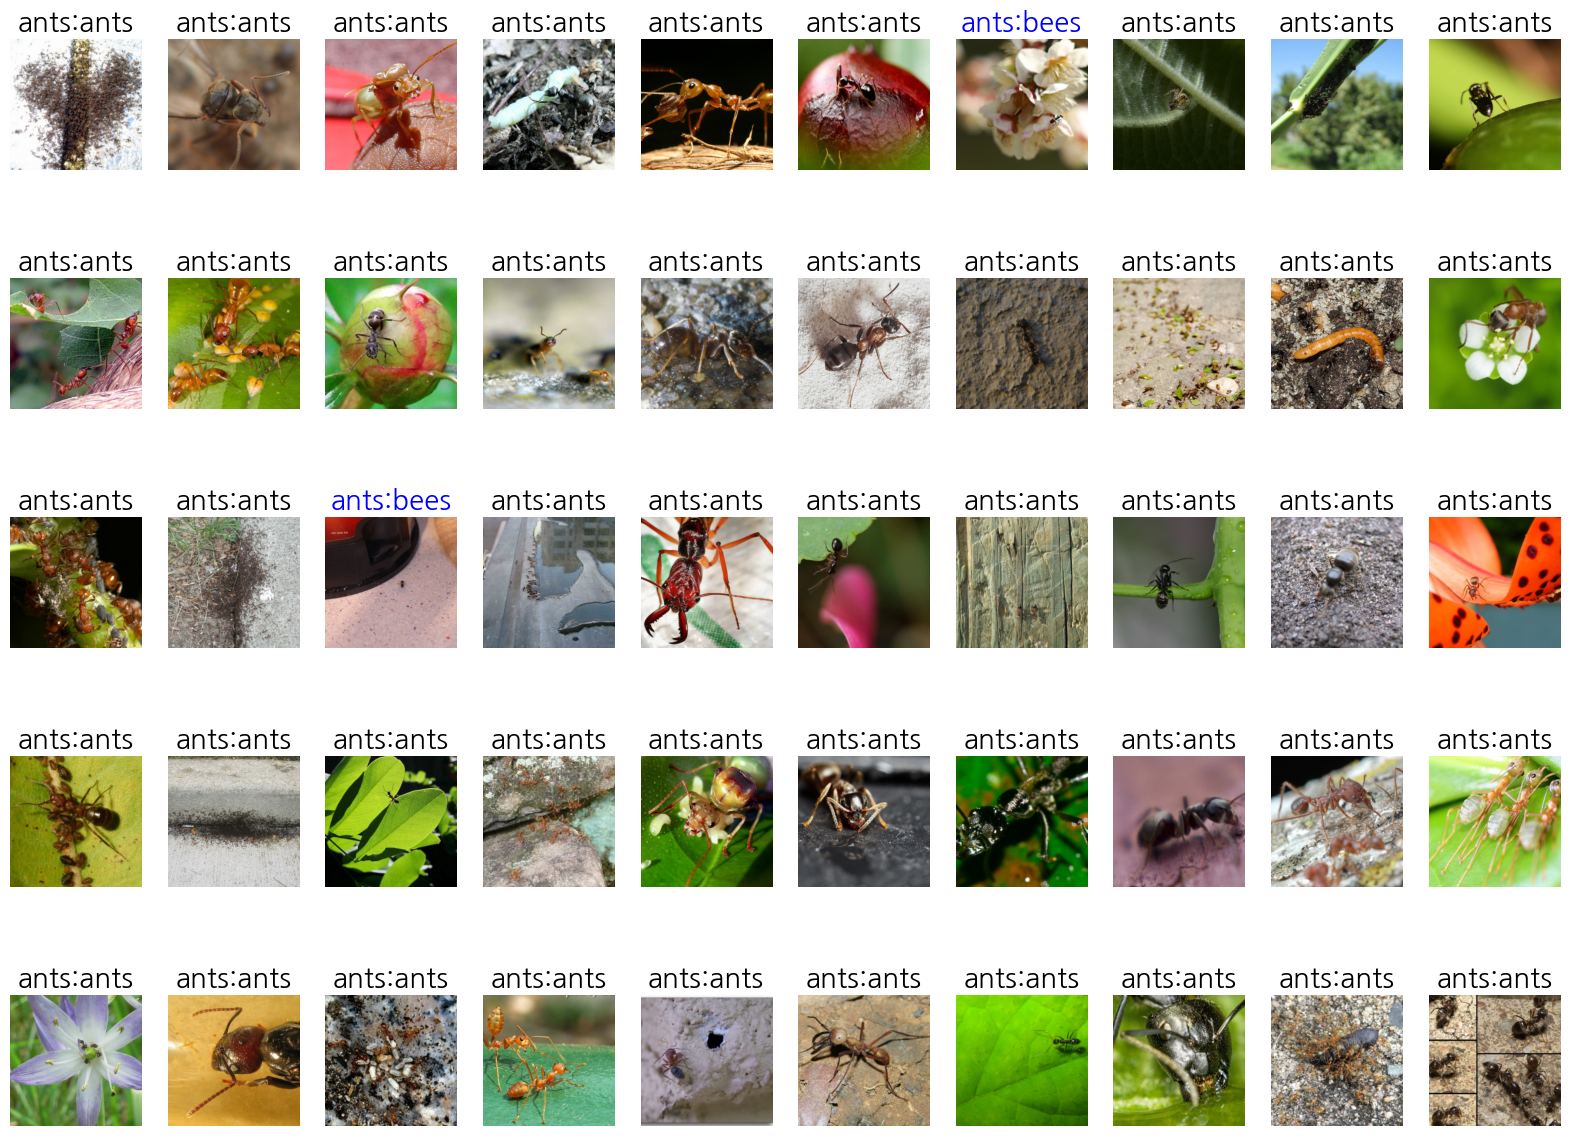

In [20]:
# 난수 고정 후, 검증 데이터 결과 출력
torch_seed()
show_images_labels(test_loader2, classes, net, device)

전이학습

In [21]:
# VGG 19 BN(batch normalization) 모델을 학습이 끝난 파라미터와 함께 불러오기
from torchvision import models

net = models.vgg19_bn(pretrained=True)

# [변경점 1] 모든 파라미터의 경사 계산을 동결(가중치 동결)
for param in net.parameters():
    param.requires_grad = False  # 가중치 동결

# 난수 고정
torch_seed()

# 최종 노드 출력 2 (이진 분류) 변경
# 이 노드에 대해서만 경사 계산 수행
in_features = net.classifier[6].in_features
net.classifier[6] = nn.Linear(in_features, 2)

# AdaptiveAvgPool2d 함수 제거
net.avgpool = nn.Identity()

net = net.to(device)

# 학습률
lr = 0.001

# 손실함수
criterion = nn.CrossEntropyLoss()

# 최적화 함수 정의
# [변경점 2] 최적화함수에 수정할 파라미터를 최종 노드로 제한
optimizer = optim.SGD(net.classifier[6].parameters(), lr=lr, momentum=0.9)

history = np.zeros((0,5))

In [22]:
# 학습
num_epochs = 5
history = fit(net, optimizer, criterion, num_epochs,
              train_loader, test_loader, device, history)

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [1/5], loss: 0.04611 acc: 0.76639 val_loss: 0.01426, val_acc: 0.96078


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [2/5], loss: 0.02377 acc: 0.90574 val_loss: 0.01292, val_acc: 0.96078


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [3/5], loss: 0.02422 acc: 0.90574 val_loss: 0.01190, val_acc: 0.96078


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [4/5], loss: 0.02325 acc: 0.89754 val_loss: 0.01307, val_acc: 0.95425


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch [5/5], loss: 0.02162 acc: 0.90574 val_loss: 0.01205, val_acc: 0.96732


초기상태 : 손실 : 0.01426  정확도 : 0.96078
최종상태 : 손실 : 0.01205 정확도 : 0.96732


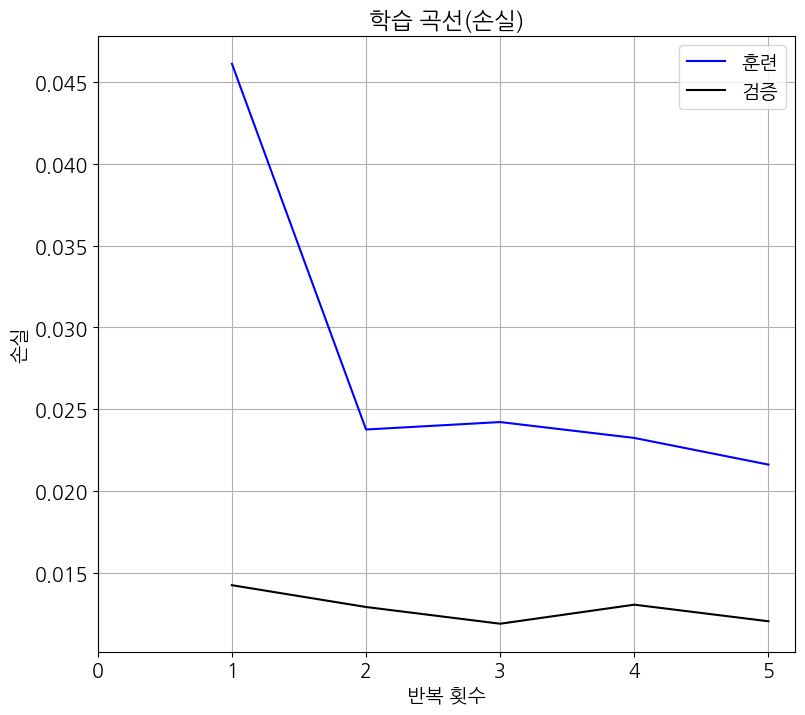

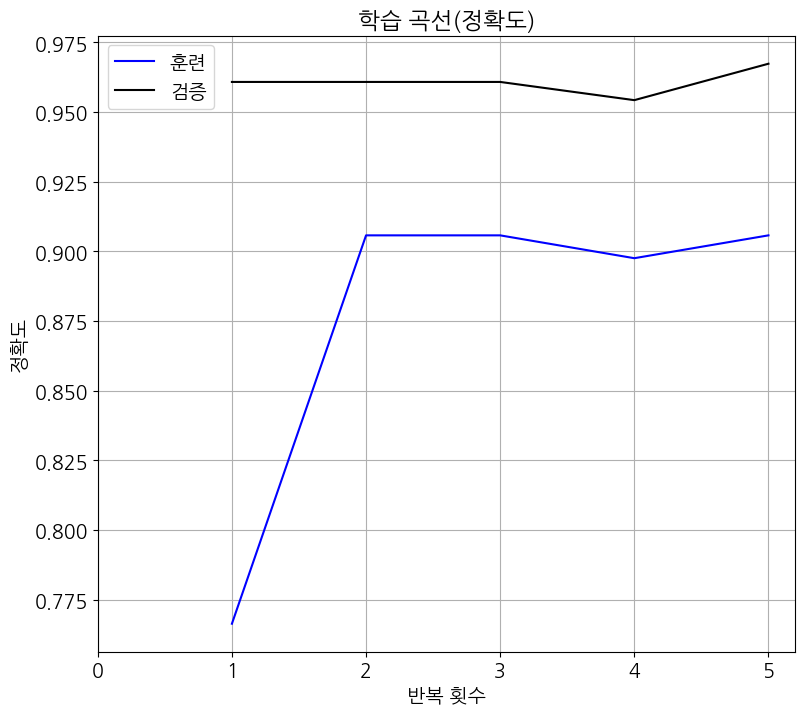

In [23]:
# 결과 확인
evaluate_history(history)

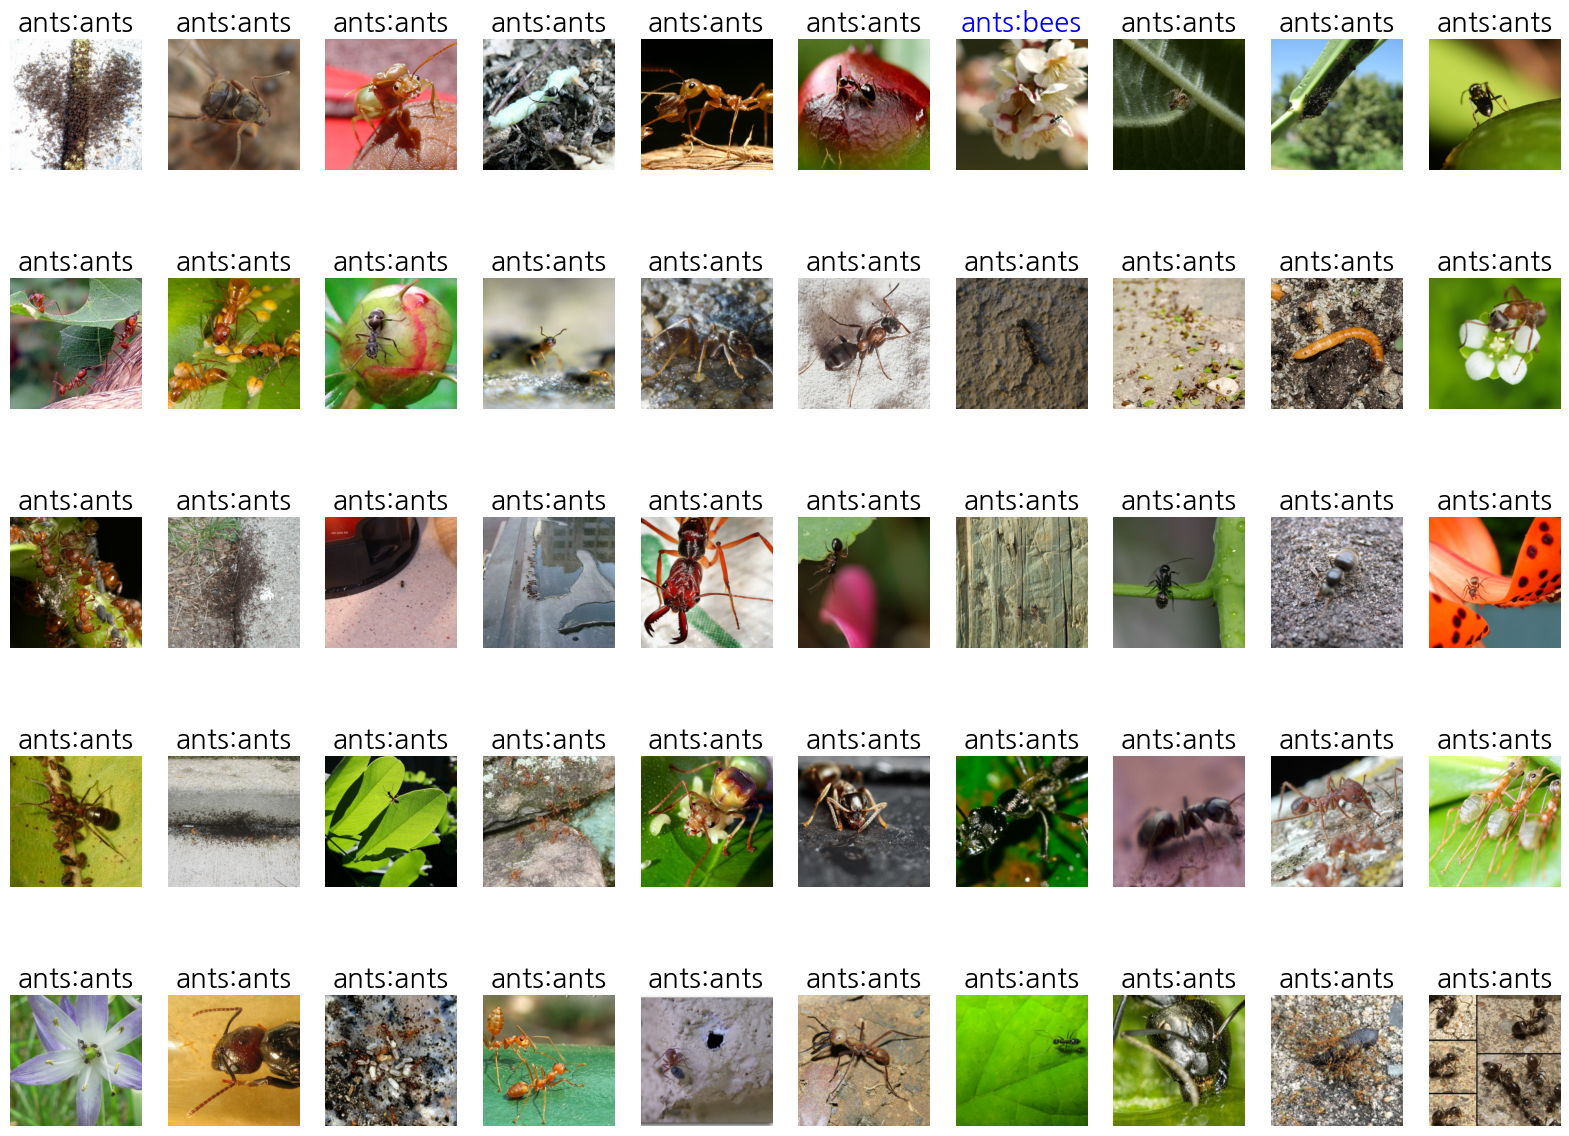

In [24]:
# 난수 고정한 후 검증 데이터 결과 출력
torch_seed()
show_images_labels(test_loader2, classes, net, device)

사용자 정의 데이터 사용하는 경우
- 시베리안 허스키 vs 늑대

In [25]:
# 데이터 다운로드
w = !wget https://github.com/makaishi2/pythonlibs/raw/main/images/dog_wolf.zip
print(w[-2])

2026-06-04 01:35:38 (473 MB/s) - ‘dog_wolf.zip’ saved [21811374/21811374]


In [26]:
# 압축해제
!unzip dog_wolf.zip |tail -n 1

  inflating: dog_wolf/train/wolf/wolf-09.png  


In [27]:
# 트리 구조 확인
!tree dog_wolf

dog_wolf
├── test
│   ├── dog
│   │   ├── dog-21.png
│   │   ├── dog-22.png
│   │   ├── dog-23.png
│   │   ├── dog-24.png
│   │   └── dog-25.png
│   └── wolf
│       ├── wolf-21.png
│       ├── wolf-22.png
│       ├── wolf-23.png
│       ├── wolf-24.png
│       └── wolf-25.png
└── train
    ├── dog
    │   ├── dog-01.png
    │   ├── dog-02.png
    │   ├── dog-03.png
    │   ├── dog-04.png
    │   ├── dog-05.png
    │   ├── dog-06.png
    │   ├── dog-07.png
    │   ├── dog-08.png
    │   ├── dog-09.png
    │   ├── dog-10.png
    │   ├── dog-11.png
    │   ├── dog-12.png
    │   ├── dog-13.png
    │   ├── dog-14.png
    │   ├── dog-15.png
    │   ├── dog-16.png
    │   ├── dog-17.png
    │   ├── dog-18.png
    │   ├── dog-19.png
    │   └── dog-20.png
    └── wolf
        ├── wolf-01.png
        ├── wolf-02.png
        ├── wolf-03.png
        ├── wolf-04.png
        ├── wolf-05.png
        ├── wolf-06.png
        ├── wolf-07.png
        ├── wolf-08.png
        ├── wolf-09.png
        ├──

Transforms 정의

In [28]:
# 검증 데이터 : 정규화
test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),

    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5)

])

# 훈련 데이터 : 정규화 + 반전, 임의로 지우기 추가
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Resize(224),
    transforms.CenterCrop(224),

    transforms.ToTensor(),
    transforms.RandomErasing(p=0.5, scale=(0.02,0.33),
                             ratio=(0.3,0.3), value=0, inplace=False),
    transforms.Normalize(0.5, 0.5)

])


In [29]:
# 데이터 셋 정의

data_dir = 'dog_wolf'

import os
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')

classes = ['dog','wolf']

# 훈련용
train_data = datasets.ImageFolder(train_dir, transform=train_transform)
# 이미지 출력용
train_data2 = datasets.ImageFolder(train_dir, transform=test_transform)
# 검증용
test_data = datasets.ImageFolder(test_dir, transform=test_transform)

In [30]:
print(f'학습데이터: {len(train_data)}')
print(f'학습데이터2: {len(train_data2)}')
print(f'검증데이터: {len(test_data)}')

학습데이터: 40
학습데이터2: 40
검증데이터: 10


In [31]:
# 데이터 로더 정의
batch_size = 5

# 훈련데이터(데이터 증강)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

# 훈련데이터2(데이터 증강 안함)
train_loader2 = DataLoader(train_data2, batch_size=batch_size, shuffle=True)

# 검증데이터
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

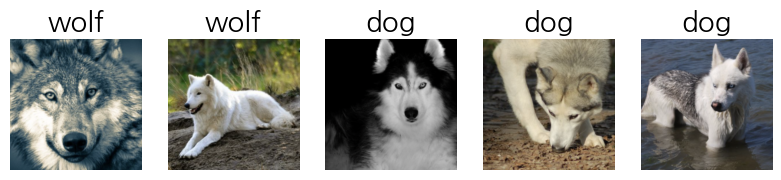

In [34]:
# 이미지 출력
show_images_labels(train_loader2, classes, None, None)

모델 정의

In [35]:
# VGG 19 BN(batch normalization) 모델을 학습이 끝난 파라미터와 함께 불러오기
from torchvision import models

net = models.vgg19_bn(pretrained=True)

# [변경점 1] 모든 파라미터의 경사 계산을 동결(가중치 동결)
for param in net.parameters():
    param.requires_grad = False  # 가중치 동결

# 난수 고정
torch_seed()

# 최종 노드 출력 2 (이진 분류) 변경
# 이 노드에 대해서만 경사 계산 수행
in_features = net.classifier[6].in_features
net.classifier[6] = nn.Linear(in_features, 2)

# AdaptiveAvgPool2d 함수 제거
net.avgpool = nn.Identity()

net = net.to(device)

# 학습률
lr = 0.001

# 손실함수
criterion = nn.CrossEntropyLoss()

# 최적화 함수 정의
# [변경점 2] 최적화함수에 수정할 파라미터를 최종 노드로 제한
optimizer = optim.SGD(net.classifier[6].parameters(), lr=lr, momentum=0.9)

history = np.zeros((0,5))

In [36]:
# 학습
num_epochs = 10
history = fit(net, optimizer, criterion, num_epochs,
              train_loader, test_loader, device, history)

  0%|          | 0/8 [00:00<?, ?it/s]

Epoch [1/10], loss: 0.11967 acc: 0.65000 val_loss: 0.07624, val_acc: 1.00000


  0%|          | 0/8 [00:00<?, ?it/s]

Epoch [2/10], loss: 0.08123 acc: 0.85000 val_loss: 0.05391, val_acc: 0.90000


  0%|          | 0/8 [00:00<?, ?it/s]

...

Epoch [8/10], loss: 0.01065 acc: 1.00000 val_loss: 0.03285, val_acc: 1.00000


  0%|          | 0/8 [00:00<?, ?it/s]

Epoch [9/10], loss: 0.04073 acc: 0.90000 val_loss: 0.03267, val_acc: 1.00000


  0%|          | 0/8 [00:00<?, ?it/s]

Epoch [10/10], loss: 0.01933 acc: 0.97500 val_loss: 0.03814, val_acc: 0.90000


초기상태 : 손실 : 0.07624  정확도 : 1.00000
최종상태 : 손실 : 0.03814 정확도 : 0.90000


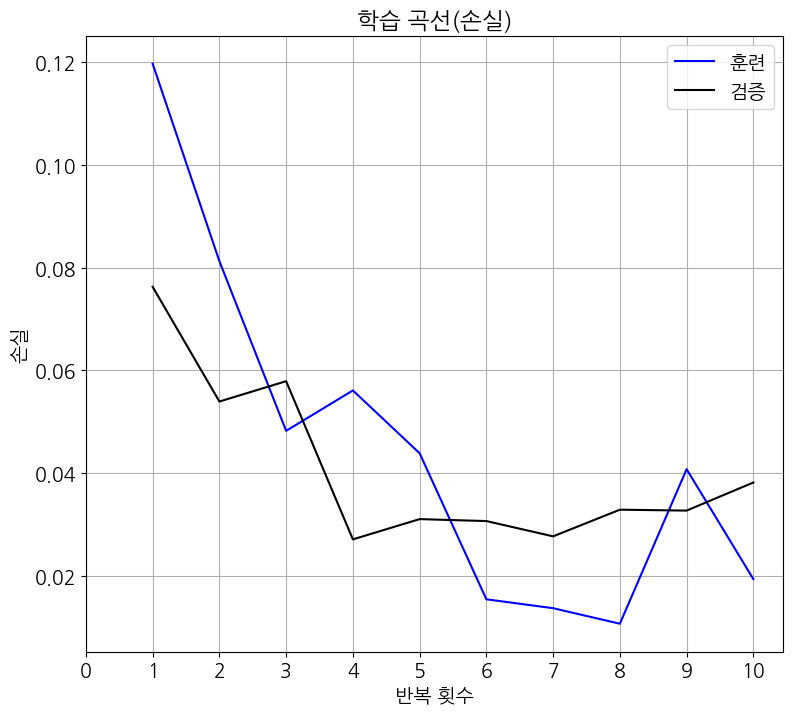

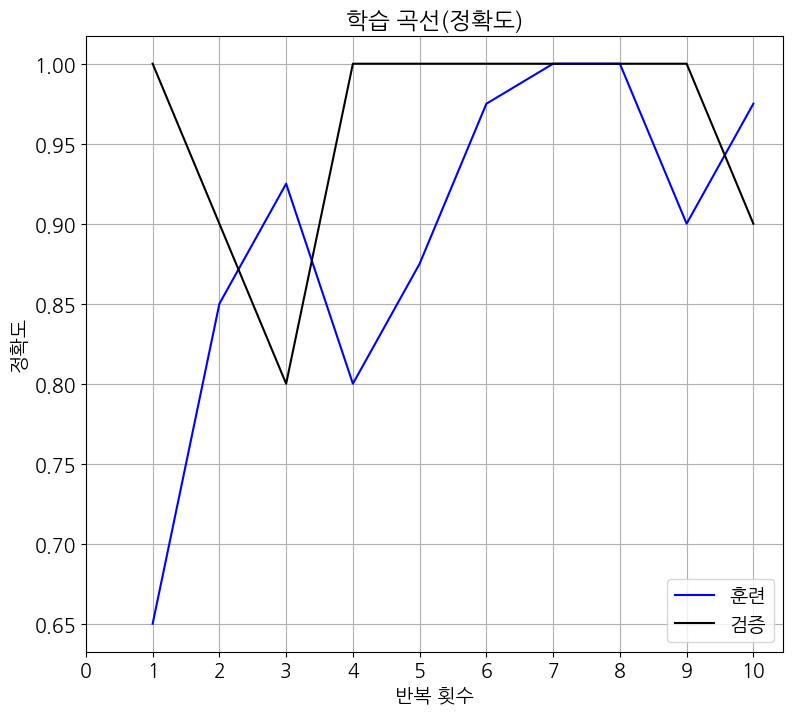

In [37]:
evaluate_history(history)

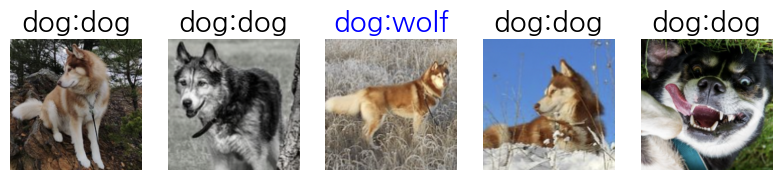

In [38]:
torch_seed()
show_images_labels(test_loader, classes, net, device)